# Preliminary Data Analysis - Expedia Hotel Search

This notebook analyzes the `train.csv` and `test.csv` datasets to identify missing data patterns and visualize label distributions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set paths
DATA_DIR = r"E:\PERSONAL_PROJ\ADTECH\data\expedia\expedia_search\data"
TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")

print(f"Data Directory: {DATA_DIR}")

Data Directory: E:\PERSONAL_PROJ\ADTECH\data\expedia\expedia_search\data


## 1. Missing Value Analysis (How many cols are empty?)

Since the datasets are large (2.3GB+), we will load a substantial sample to get a representative look at missing values, or process in chunks if memory is tight.

In [2]:
def analyze_missing(path, name, nrows=1000000):
    print(f"Analyzing {name} (first {nrows} rows)...")
    df = pd.read_csv(path, nrows=nrows)
    null_counts = df.isnull().sum()
    null_pct = (null_counts / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Missing Values': null_counts,
        'Percentage (%)': null_pct
    }).sort_values('Percentage (%)', ascending=False)
    
    return missing_df

train_summary = analyze_missing(TRAIN_PATH, "Train")
print("\n--- Train Missing Values (Top 10) ---")
print(train_summary.head(10))

test_summary = analyze_missing(TEST_PATH, "Test")
print("\n--- Test Missing Values (Top 10) ---")
print(test_summary.head(10))

Analyzing Train (first 1000000 rows)...

--- Train Missing Values (Top 10) ---
                         Missing Values  Percentage (%)
comp1_rate_percent_diff          981548         98.1548
comp6_rate_percent_diff          980796         98.0796
comp1_rate                       976670         97.6670
comp1_inv                        974711         97.4711
comp4_rate_percent_diff          973543         97.3543
gross_bookings_usd               972262         97.2262
comp7_rate_percent_diff          972143         97.2143
comp6_rate                       951445         95.1445
visitor_hist_starrating          948424         94.8424
visitor_hist_adr_usd             948227         94.8227
Analyzing Test (first 1000000 rows)...

--- Test Missing Values (Top 10) ---
                         Missing Values  Percentage (%)
comp1_rate_percent_diff          981892         98.1892
comp6_rate_percent_diff          980353         98.0353
comp1_rate                       976877         97.6877
comp

## 2. Label Distributions

Plotting `booking_bool` and `click_bool` from the train set.

Loading labels for visualization...


C:\Users\user\AppData\Local\Temp\ipykernel_16844\1414663960.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='booking_bool', data=labels_df, ax=ax[0], palette='viridis')
C:\Users\user\AppData\Local\Temp\ipykernel_16844\1414663960.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='click_bool', data=labels_df, ax=ax[1], palette='magma')


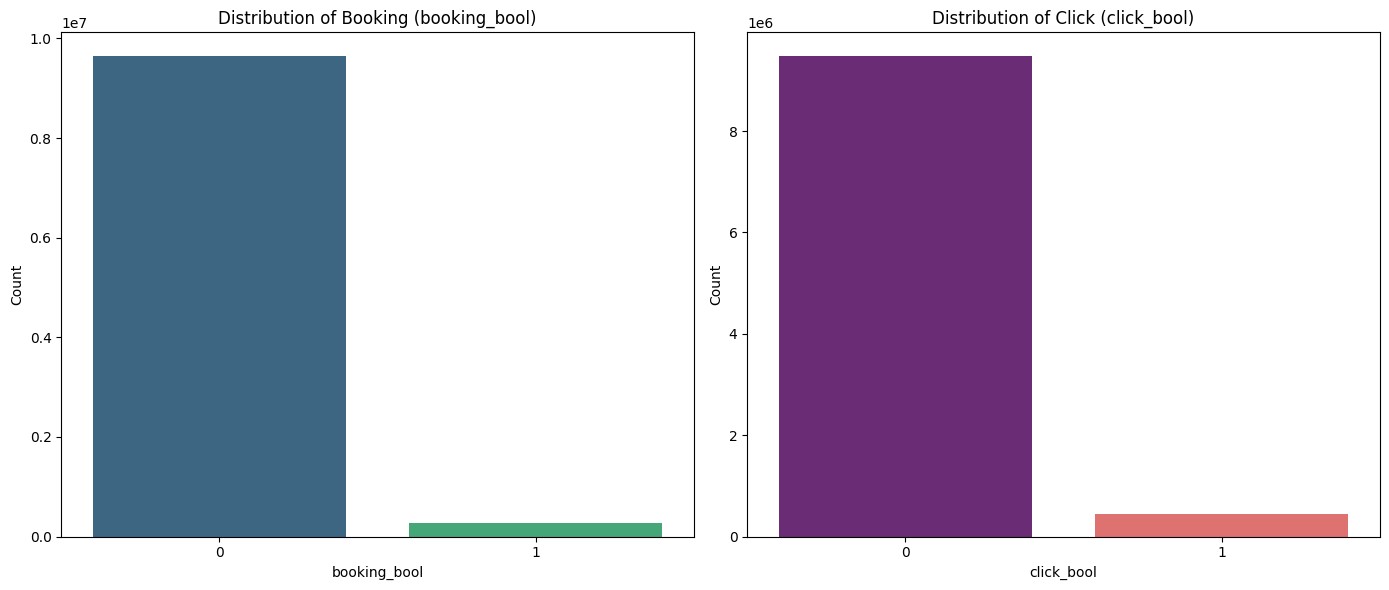

Value Counts:

Booking Bool:
booking_bool
0    0.972111
1    0.027889
Name: proportion, dtype: float64

Click Bool:
click_bool
0    0.955264
1    0.044736
Name: proportion, dtype: float64


In [3]:
print("Loading labels for visualization...")
# Read only the label columns to save memory
labels_df = pd.read_csv(TRAIN_PATH, usecols=['booking_bool', 'click_bool'])

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(x='booking_bool', data=labels_df, ax=ax[0], palette='viridis')
ax[0].set_title('Distribution of Booking (booking_bool)')
ax[0].set_ylabel('Count')

sns.countplot(x='click_bool', data=labels_df, ax=ax[1], palette='magma')
ax[1].set_title('Distribution of Click (click_bool)')
ax[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("Value Counts:")
print("\nBooking Bool:")
print(labels_df['booking_bool'].value_counts(normalize=True))
print("\nClick Bool:")
print(labels_df['click_bool'].value_counts(normalize=True))